## Outline of the project

The aim of the project is to practically learn and implement CNN.

Section 1: Build a convolutional layer and pooling layer from scratch. Then test them on a sample image.

Section 2: Use the Keras library to implement a CNN to classify images on the [CIFAR10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html).

***


Use the below cell to use any include any imports

In [16]:
import time
starting_time = time.time()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import random
from keras.preprocessing.image import load_img
import keras
from scipy import signal

## 1: Convolution and Pooling

 Padding implementation. The method will take in input_image ($n \times m$) and will return a zero-padded image called output_image of dimension $(n + 2d) \times (m + 2d)$ where $d$ is the padding thickness on either side.

In [18]:
def create_padding(input_image, d):

    n, m = input_image.shape
    output_image = np.zeros((n + 2 * d, m + 2 * d), dtype=input_image.dtype)
    output_image[d:d + n, d:d + m] = input_image

    return output_image


In [19]:
input_image = np.array([[1, 2], [3, 4]])
padded_image = create_padding(input_image, 1)
print(padded_image)


[[0 0 0 0]
 [0 1 2 0]
 [0 3 4 0]
 [0 0 0 0]]


Convolution implementation. The method will take in input_image ($n \times m$), kernel ($k \times k$) and will return output_image of dimension $(n - k + 1) \times (m - k + 1)$. The output_image is the result of the convolution between input_image and kernel.

In [20]:
def convolution(input_image, kernel):
    n, m = input_image.shape
    k, _ = kernel.shape

    # Determine output dimensions
    output_height = n - k + 1
    output_width = m - k + 1

    # Initialize the output image
    output_image = np.zeros((output_height, output_width), dtype=np.float64)

    # Perform convolution
    for i in range(output_height):
        for j in range(output_width):
            region = input_image[i:i + k, j:j + k]
            output_image[i, j] = np.sum(region * kernel)

    return output_image


In [21]:
input_image = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])

kernel = np.array([[1, 0],
                   [0, -1]])

output = convolution(input_image, kernel)
print(output)


[[-4. -4.]
 [-4. -4.]]


Pooling implementation. The method will take in input_image ($n \times m$), $p$ the pooling dimension, pooling_type (either max_pooling or avg_pooling) and will return output_image of dimension $(n - p + 1) \times (m - p + 1)$. The output_image is the result of performing pooling on input_image by a window of dimension $p \times p$.

In [22]:
def pooling(input_image, p, pooling_type="max_pooling"):
    n, m = input_image.shape

    output_height = n - p + 1
    output_width = m - p + 1

    output_image = np.zeros((output_height, output_width), dtype=np.float64)

    for i in range(output_height):
        for j in range(output_width):
            window = input_image[i:i + p, j:j + p]
            if pooling_type == "max_pooling":
                output_image[i, j] = np.max(window)
            elif pooling_type == "avg_pooling":
                output_image[i, j] = np.mean(window)
            else:
                print("Error: Invalid pooling type")
                return None

    return output_image


In [23]:
input_image = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])

print("Max pooling:\n", pooling(input_image, 2, "max_pooling"))
print("Avg pooling:\n", pooling(input_image, 2, "avg_pooling"))


Max pooling:
 [[5. 6.]
 [8. 9.]]
Avg pooling:
 [[3. 4.]
 [6. 7.]]


The 'lena' image is widely used for image processing experiments and has been a benchmark image until recently.
A $512 \times 512$ grayscale lena sample is used to test convolution and pooling implementations.

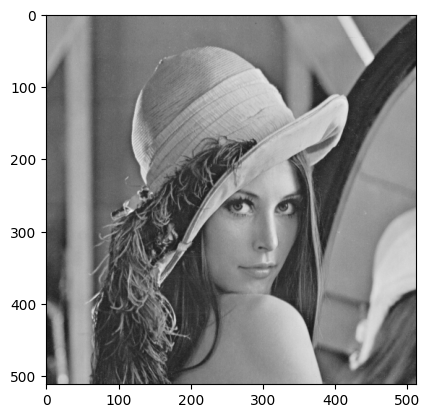

In [24]:
lena = load_img('lena.gif')
plt.imshow(lena)
plt.show()

**Q4** Performing convolution on lena using below kernals.

1. $\begin{bmatrix} +1 & 0 & -1 \\ +1 & 0 & -1 \\ +1 & 0 & -1 \end{bmatrix}$
   
2. $\begin{bmatrix} -1 & -1 & -1 \\ 0 & 0 & 0 \\ +1 & +1 & +1 \end{bmatrix}$

3. $\begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix}$

4. $\begin{bmatrix} +1 & +2 & +1 \\ 0 & 0 & 0 \\ -1 & -2 & -1 \end{bmatrix}$

4. $\begin{bmatrix} 0 & +1 & 0 \\ -1 & +5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$


In [25]:
# Define kernels
kernels = [
    np.array([[+1, 0, -1], [+1, 0, -1], [+1, 0, -1]]),  # Kernel 1
    np.array([[-1, -1, -1], [0, 0, 0], [+1, +1, +1]]),  # Kernel 2
    np.array([[-1, 0, +1], [-2, 0, +2], [-1, 0, +1]]),  # Kernel 3
    np.array([[+1, +2, +1], [0, 0, 0], [-1, -2, -1]]),  # Kernel 4
    np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])     # Kernel 5
]

#  Perform padded convolution then pooling
def apply_kernel_and_pool(image, kernel, pool_type="max_pooling"):
    padded = create_padding(image, kernel.shape[0] // 2)
    convolved = convolution(padded, kernel)
    pooled = pooling(convolved, 2, pooling_type=pool_type)
    return convolved, pooled

# Load the image and convert it to grayscale
lena = np.array(load_img('lena.gif').convert('L'))  # Convert to grayscale

results = []
results.append(apply_kernel_and_pool(lena, kernels[0], "max_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[1], "avg_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[2], "max_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[3], "avg_pooling"))
results.append(apply_kernel_and_pool(lena, kernels[4], "max_pooling"))

# outputs
lena_kernel_1_maxpool = results[0][1]
lena_kernel_2_avgpool = results[1][1]
lena_kernel_3_maxpool = results[2][1]
lena_kernel_4_avgpool = results[3][1]

Resulting images after pooling and convolution

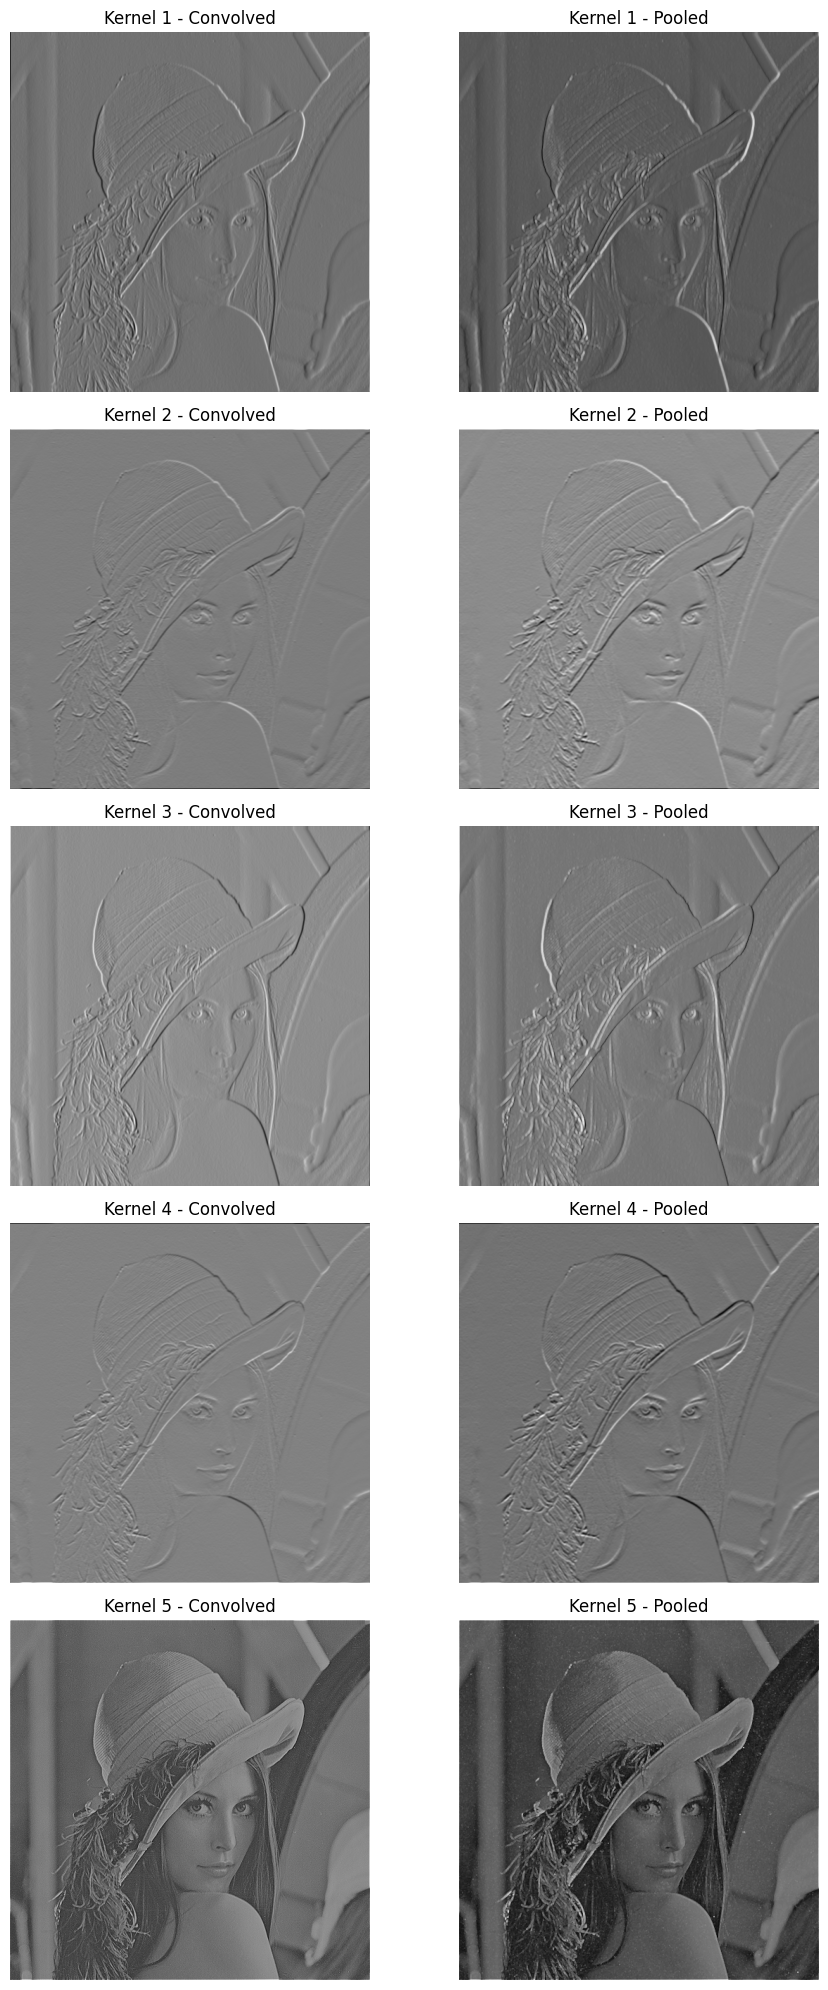

In [26]:
# Plotting
fig, axes = plt.subplots(5, 2, figsize=(10, 20))
titles = ["Kernel 1", "Kernel 2", "Kernel 3", "Kernel 4", "Kernel 5"]
for i in range(5):
    convolved, pooled = results[i]
    axes[i, 0].imshow(convolved, cmap='gray')
    axes[i, 0].set_title(f'{titles[i]} - Convolved')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(pooled, cmap='gray')
    axes[i, 1].set_title(f'{titles[i]} - Pooled')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 2: Using Keras to implement CNN for image classification

When implementing this I'm trying to achieve a balance between accuracy and efficiency. Making the whole notebook run under 240s

In [27]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [28]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import random

# Optional: Use all CPU threads
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

random.seed(32)    #32 , 64
np.random.seed(32)
tf.random.set_seed(32)

# Classes for output mapping
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Load CIFAR-10, use only a small subset for training
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()

# Fast/small model
def create_fast_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),   

        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
    
model = create_fast_model()
model.fit(x_train, y_train, epochs=10, batch_size=256, verbose=0)

In [29]:
#In this cell define the function predict, which will predict the class of test_images using your best CNN-model.
#The output should be a python list of strings of classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
#Your work will be mainly evaluated based on this.
#The grader will test it against input images and your score will be determined based on the number of correct predictions.
#Expect the input to be a torch tensor of shape [64, 3, 32, 32]

# Predict function, input is torch tensor
def predict(test_images, batch_size=256):
    # test_images: torch.Tensor of shape (N, 3, 32, 32)
    np_images = test_images.numpy()  # shape: (N, 3, 32, 32)
    np_images = np.transpose(np_images, (0, 2, 3, 1))  # shape: (N, 32, 32, 3)

    # Normalize if needed
    if np_images.max() > 1.0:
        np_images = np_images.astype("float32") / 255.0

    # Predict using Keras model
    preds = model.predict(np_images, batch_size=batch_size, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    predictions = [class_names[i] for i in pred_labels]
    return predictions

In [30]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
end_time = time.time()
print("Total execution time:", end_time - starting_time, "seconds")

Test accuracy: 0.6963
Total execution time: 63.24927091598511 seconds
